# Packages and Setup

In [ ]:
import numpy as np
import random
import importlib as imp
import generative_functions as gf
import gcn_functions as gcnf
imp.reload(gf)
imp.reload(gcnf)
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.loader import DataLoader

seed = 78
random.seed(seed)
np.random.seed(seed)

print('Packages imported and seed set.')

ModuleNotFoundError: No module named 'torch_geometric'

# Problem introduction

This project aims to compare the classification abilities and robustness of different models (Random Forest, SVM, GNN) and features to correctly classify (non-oriented) graphs generated from four different generative models :
- the Erdös-Rényi random graphs model (ER),
- the Barabasi-Albert preferential attachment model (BA),
- the Watts-Strogatz small-world model (WS)
- the Stochastich Block Model (SBM).

We are going to conduct several experiments to assess those classification power and robustness :
- A baseline experiment where we set the density of each type of graph to a different value. This should lead to an easier classification but a poor generalization (and then poor robustness).
- A density-controlled experiment were we set the density to a given number for all the models. This should lead the classification models to leverage characteristics beyond the density or the average degree.
- A density-controlled experiment + training and test on graphs of different sizes ($n = 100$ for training and $n = 200$ for test). This allows to evaluate if the classification models are robust for graph of different (and unseen) sizes.
- A density-controlled experiment + random edge perturbations to see if
the models are robust to more realistic graphs (with errors and noise in the connections).

# Baseline Experiment

## Generating data

Let's set the number of nodes per graph at $n = 200$. To ensure the graphs are not too spare or too dense, let's say we want an average degree between $4$ and $12$. Since we want the density (the average degree) of the generated graphs to be different from one model to an other, let's set a specific target average degree for each generative model : ER -> 4, BA -> 7, WS -> 10, SBM -> 12


In [66]:
# Baseline setup: different densities across graph types
n = 200
avg_degrees = [4, 7, 10, 12]  # ER, BA, WS, SBM
num_graphs_per_class = 200

graph_dataset = gf.create_graph_dataset(n, avg_degrees, num_graphs_per_class, seed=seed)
print('Graphs dataset created.')

Graphs dataset created.


## Random Forest & SVM

In [67]:
# Creating and splitting features dataset

features_dataset = gf.create_features_dataset(graph_dataset)
X = features_dataset.drop(columns = ['target'])
y = features_dataset['target']

X_train, X_val, X_test, y_train, y_val, y_test = gf.splitting(X = X, y = y, seed=seed)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (559, 27) Val: (121, 27) Test: (120, 27)


In [68]:
# Creating and training the Random Forest & SVM models

models = {
    'RandomForest': RandomForestClassifier(n_estimators = 300, random_state = seed, n_jobs=-1),
    'SVM_Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel = 'linear', C = 10, gamma = 'scale'))
    ])
}

fitted_models = {}
val_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    val_rows.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_macro_f1': f1_score(y_val, y_val_pred, average = 'macro')
    })

    fitted_models[name] = model

for m in val_rows:
  print(f'Model : {m['model']} ', '\n', f'Val Accuracy : {m['val_accuracy']}', '\n', f'Val F1: {m['val_macro_f1']}', '\n')

Model : RandomForest  
 Val Accuracy : 1.0 
 Val F1: 1.0 

Model : SVM_Linear  
 Val Accuracy : 1.0 
 Val F1: 1.0 



The classification is perfect (which was expected since the classification task is easy), no need to change the hyperparameters.

## GCN

In [69]:
# Creating 3 sets : Train, Val, Test
train, val, test = gf.splitting(graph_dataset, seed=seed)

train_pyg = gcnf.nx_to_pyg(train)
val_pyg = gcnf.nx_to_pyg(val)
test_pyg = gcnf.nx_to_pyg(test)

print('Train:', len(train_pyg), 'Val:', len(val_pyg), 'Test:', len(test_pyg))

# Creating dataloaders with a batch_size of 16
train_loader = DataLoader(train_pyg, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_pyg, batch_size = 16, shuffle = False)
test_loader = DataLoader(test_pyg, batch_size = 16, shuffle = False)


Train: 559 Val: 121 Test: 120


In [70]:
# Creating the GCN

model_gcn = gcnf.GCN(hidden_channels = 64)
optimizer = torch.optim.Adam(model_gcn.parameters(), lr = 0.01)
criterion = torch.nn.CrossEntropyLoss()

print('GCN created.')

GCN created.


In [71]:
# Training the GCN

def train():
    model_gcn.train()
    for data in train_loader:
        out = model_gcn(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def test(loader):
    model_gcn.eval()
    correct = 0
    with torch.no_grad():
        for data in loader:
            out = model_gcn(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim = 1)
            correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)

for epoch in range(1, 51):
    train()
    if epoch % 10 == 0:
        val_acc = test(val_loader)
        print(f'Epoch: {epoch:03d}, Val Acc: {val_acc:.4f}')

Epoch: 010, Val Acc: 1.0000
Epoch: 020, Val Acc: 1.0000
Epoch: 030, Val Acc: 1.0000
Epoch: 040, Val Acc: 1.0000
Epoch: 050, Val Acc: 1.0000


## Results

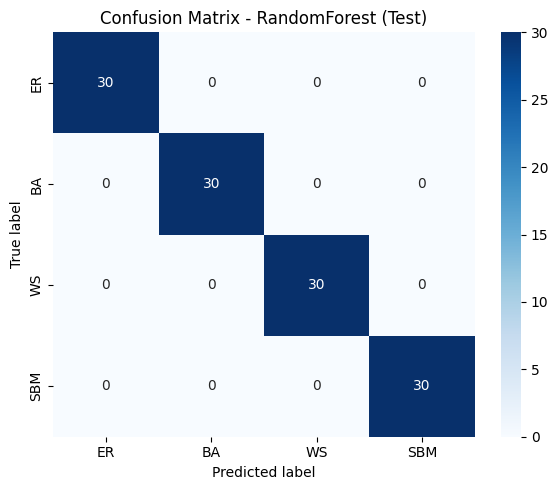

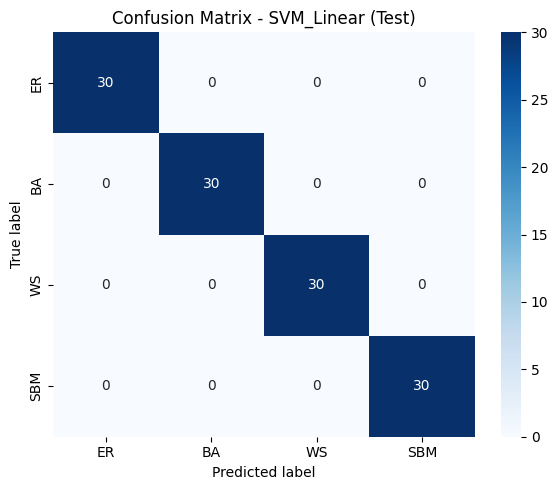

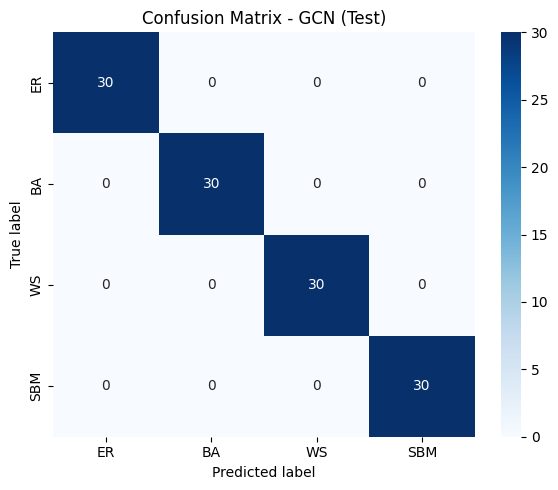

In [72]:
# Combine all models for evaluation
# fitted_models already contains RandomForest and SVM_RBF from previous steps
all_models_to_evaluate = fitted_models.copy()
all_models_to_evaluate['GCN'] = model_gcn

# Prepare labels and class names
labels = [0, 1, 2, 3]
class_names = ['ER', 'BA', 'WS', 'SBM']

results_rows = []

for name, model in all_models_to_evaluate.items():
    if name == 'GCN':
        y_test_true, y_test_pred = gcnf.get_gcn_predictions(model, test_loader)
    else:
        y_test_pred = model.predict(X_test)
        y_test_true = y_test # For non-GCN models, y_test is already the true labels

    accuracy = accuracy_score(y_test_true, y_test_pred)
    macro_f1 = f1_score(y_test_true, y_test_pred, average='macro')

    results_rows.append({
        'model': name,
        'test_accuracy': accuracy,
        'test_macro_f1': macro_f1
    })

    cm = confusion_matrix(y_test_true, y_test_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix - {name} (Test)')
    plt.tight_layout()
    plt.show()

Random Forest and SVM perfectly classify graphs. Let's see what is the importance of each feature in this classification.

For the RF model, we are going to use the ```feature_importances_```.

## Importance of features : RF model

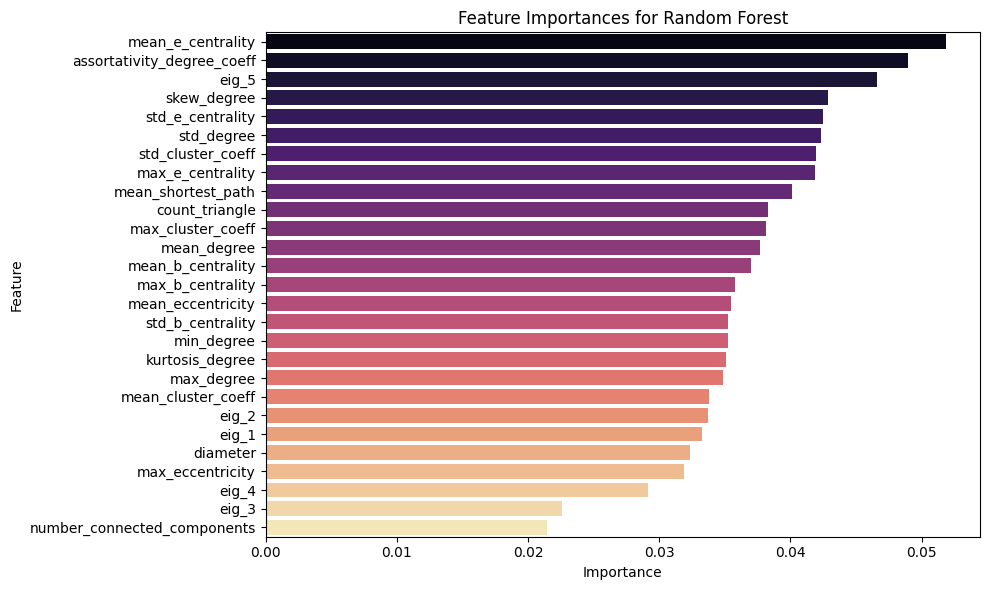

In [73]:
rf_importances = pd.Series(
    fitted_models['RandomForest'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=rf_importances.values,
    y=rf_importances.index,
    hue=rf_importances.index,
    palette='magma'
)
plt.title('Feature Importances for Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The features ```mean_e_centrality```, ```assortativity_degree_coeff``` and ```eig_5``` are the most informative one. We thought that the feature ```mean_degree``` would be really impactful since the mean degree of each type of graph was set to a different value. Actually, the ```feature_importances_``` function provides the importance of each feature relatively to the other's, so ```mean_degree``` might be very impactful, yet less than ```mean_e_centrality``` or ```assortativity_degree_coeff```. 

Let's train two other models and see if they perform well :
- one with only ```mean_e_centrality```, ```assortativity_degree_coeff``` and ```eig_5``` as predictive features
- and one with only ```mean_degree``` as a predictive feature

Model : ['mean_degree']  
 Test Accuracy : 1.0 
 Test F1: 1.0 



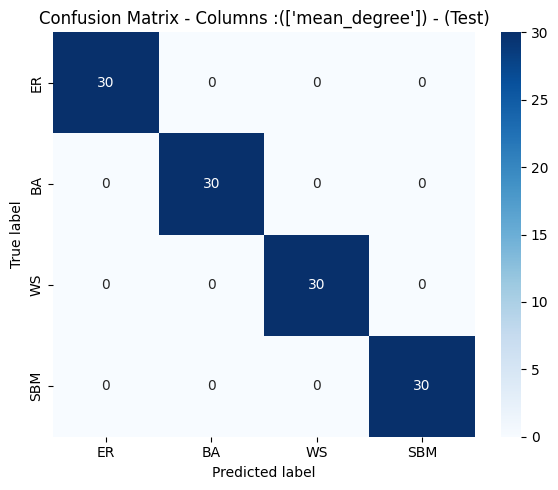

Model : ['mean_e_centrality', 'assortativity_degree_coeff', 'eig_5']  
 Test Accuracy : 1.0 
 Test F1: 1.0 



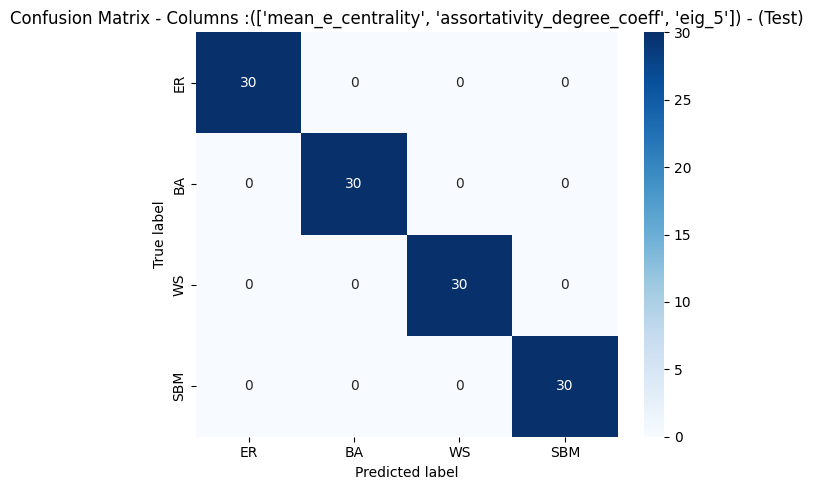

In [74]:
predictive_features = [['mean_degree'], ['mean_e_centrality', 'assortativity_degree_coeff', 'eig_5']]
model = RandomForestClassifier(n_estimators = 300, random_state = seed, n_jobs=-1)

for f in predictive_features:
    fitted_model = clone(model)
    fitted_model.fit(X_train[f], y_train)
    y_test_pred = fitted_model.predict(X_test[f])

    metrics = {
        'columns': f,
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_macro_f1': f1_score(y_test, y_test_pred, average = 'macro')
    }
    
    print(f'Model : {metrics['columns']} ', '\n', f'Test Accuracy : {metrics['test_accuracy']}', '\n', f'Test F1: {metrics['test_macro_f1']}', '\n')

    cm = confusion_matrix(y_test, y_test_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix - Columns :({f}) - (Test)')
    plt.tight_layout()
    plt.show()

Both submodels are perfectly classifying the graphs. It seems that setting distinct average degree for distinct types of graph makes the graphs so different that a RF classifier can predict the type of the graph using not the most immediate features. It will be interesting to see what features are used by a RF in the coming experiments and what is the importance of ```mean_degree``` (it should lose its predictive power).

## Importance of features : GCN

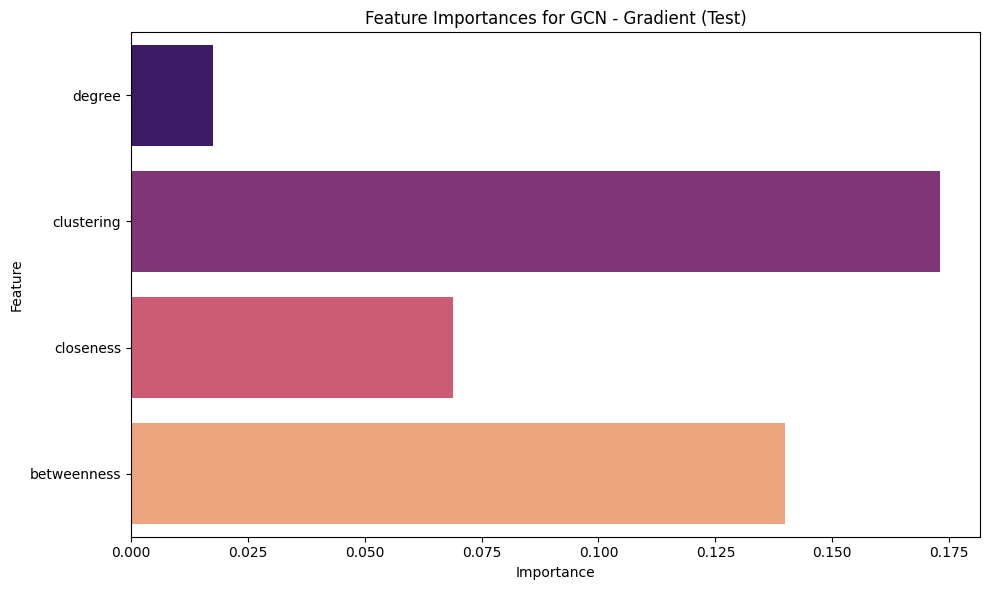

In [75]:
gcn_importances = gcnf.gradient_feature_importance(model_gcn, test_loader)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=gcn_importances.values(),
    y=gcn_importances.keys(),
    hue=gcn_importances.keys(),
    palette='magma'
)
plt.title('Feature Importances for GCN - Gradient (Test)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Density-Controlled Experiment


Let's set the number of nodes per graph at $n = 200$ and the density of all graphs at 8.


In [76]:
# Density-Controlled setup: same density across graph types
n = 200
avg_degrees = 8
num_graphs_per_class = 200

graph_dataset = gf.create_graph_dataset(n, avg_degrees, num_graphs_per_class)
print('Graphs dataset created.')

Graphs dataset created.


## Random Forest & SVM

In [77]:
# Creating and splitting features dataset

features_dataset = gf.create_features_dataset(graph_dataset)
X = features_dataset.drop(columns = ['target'])
y = features_dataset['target']

X_train, X_val, X_test, y_train, y_val, y_test = gf.splitting(seed = seed, X = X, y = y)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (559, 27) Val: (121, 27) Test: (120, 27)


In [78]:
# Training the Random Forest & SVM models

models = {
    'RandomForest': RandomForestClassifier(n_estimators = 300, random_state = seed, n_jobs=-1),
    'SVM_Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel = 'linear', C = 10, gamma = 'scale'))
    ])
}

fitted_models = {}
val_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    val_rows.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_macro_f1': f1_score(y_val, y_val_pred, average='macro')
    })

    fitted_models[name] = model

for m in val_rows:
  print(f'Model : {m['model']} ', '\n', f'Val Accuracy : {m['val_accuracy']}', '\n', f'Val F1: {m['val_macro_f1']}', '\n')

Model : RandomForest  
 Val Accuracy : 1.0 
 Val F1: 1.0 

Model : SVM_Linear  
 Val Accuracy : 1.0 
 Val F1: 1.0 



## GCN

In [79]:
# Creating 3 sets : Train, Val, Test
train, val, test = gf.splitting(graph_dataset, seed=seed)

train_pyg = gcnf.nx_to_pyg(train)
val_pyg   = gcnf.nx_to_pyg(val)
test_pyg  = gcnf.nx_to_pyg(test)

print('Train:', len(train_pyg), 'Val:', len(val_pyg), 'Test:', len(test_pyg))

# Creating dataloaders with a batch_size of 16
train_loader = DataLoader(train_pyg, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_pyg,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_pyg,  batch_size=16, shuffle=False)

Train: 559 Val: 121 Test: 120


In [80]:
# Creating the GCN

model_gcn = gcnf.GCN(hidden_channels=64)
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

print('GCN created.')

GCN created.


In [81]:
# Training the GCN

def train():
    model_gcn.train()
    for data in train_loader:
        out = model_gcn(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def test(loader):
    model_gcn.eval()
    correct = 0
    with torch.no_grad():
        for data in loader:
            out = model_gcn(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)

for epoch in range(1, 51):
    train()
    if epoch % 10 == 0:
        val_acc = test(val_loader)
        print(f'Epoch: {epoch:03d}, Val Acc: {val_acc:.4f}')

Epoch: 010, Val Acc: 0.9008
Epoch: 020, Val Acc: 0.8678
Epoch: 030, Val Acc: 0.9917
Epoch: 040, Val Acc: 0.9917
Epoch: 050, Val Acc: 0.9917


## Results

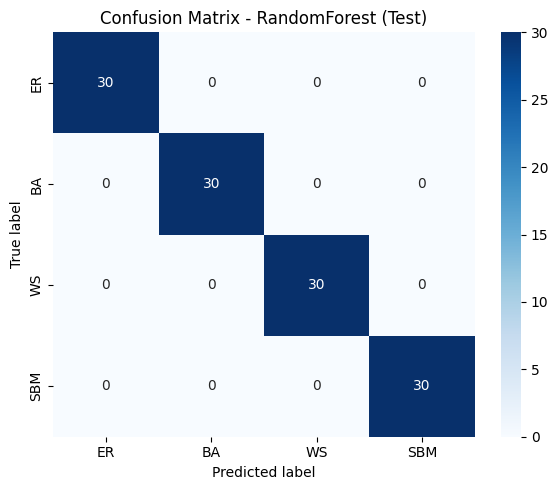

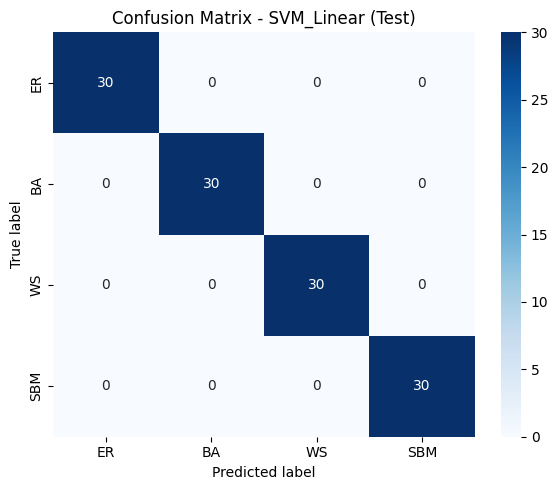

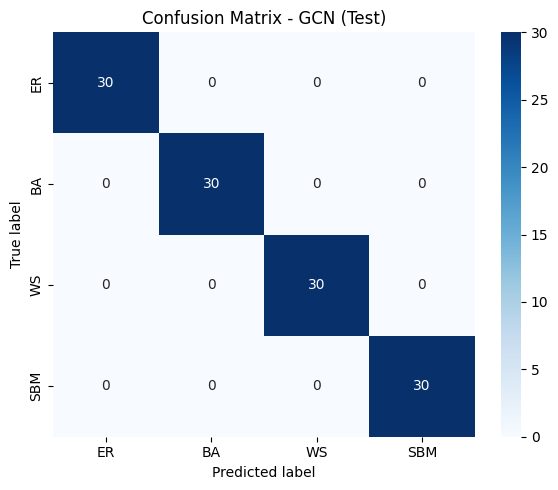

In [82]:
# Combine all models for evaluation
# fitted_models already contains RandomForest and SVM_Linear from previous steps
all_models_to_evaluate = fitted_models.copy()
all_models_to_evaluate['GCN'] = model_gcn

# Prepare labels and class names
labels = [0, 1, 2, 3]
class_names = ['ER', 'BA', 'WS', 'SBM']

results_rows = []

for name, model in all_models_to_evaluate.items():
    if name == 'GCN':
        y_test_true, y_test_pred = gcnf.get_gcn_predictions(model, test_loader)
    else:
        y_test_pred = model.predict(X_test)
        y_test_true = y_test

    accuracy = accuracy_score(y_test_true, y_test_pred)
    macro_f1 = f1_score(y_test_true, y_test_pred, average='macro')

    results_rows.append({
        'model': name,
        'test_accuracy': accuracy,
        'test_macro_f1': macro_f1
    })

    cm = confusion_matrix(y_test_true, y_test_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix - {name} (Test)')
    plt.tight_layout()
    plt.show()

## Importance of features : RF model

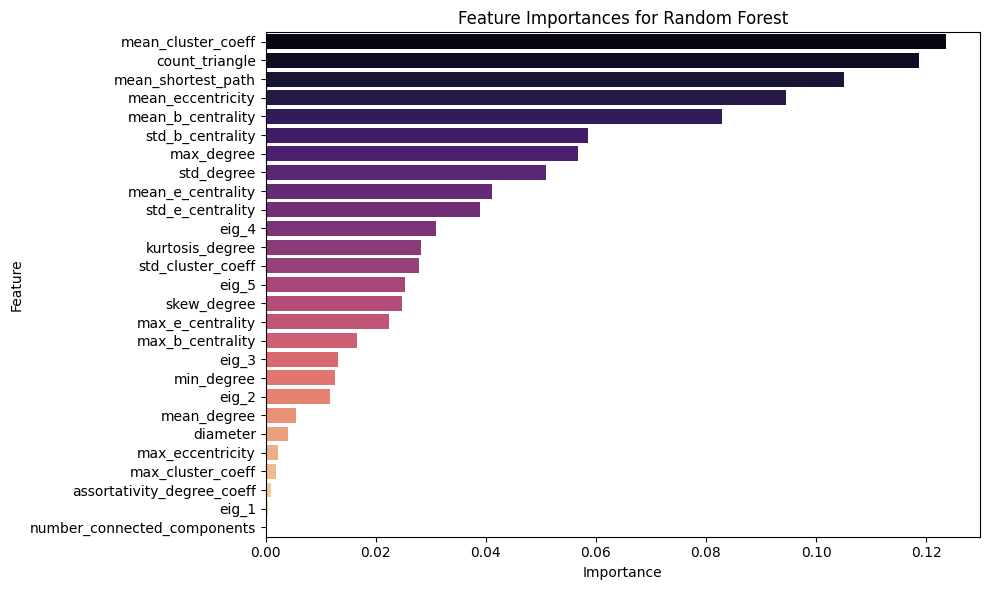

In [83]:
# Feature Importance
rf_importances = pd.Series(fitted_models['RandomForest'].feature_importances_, index = X_train.columns).sort_values(ascending = False)

plt.figure(figsize=(10, 6))
sns.barplot(x = rf_importances.values, y = rf_importances.index, hue = rf_importances.index, palette = 'magma',)
plt.title('Feature Importances for Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Importance of features : SVM model

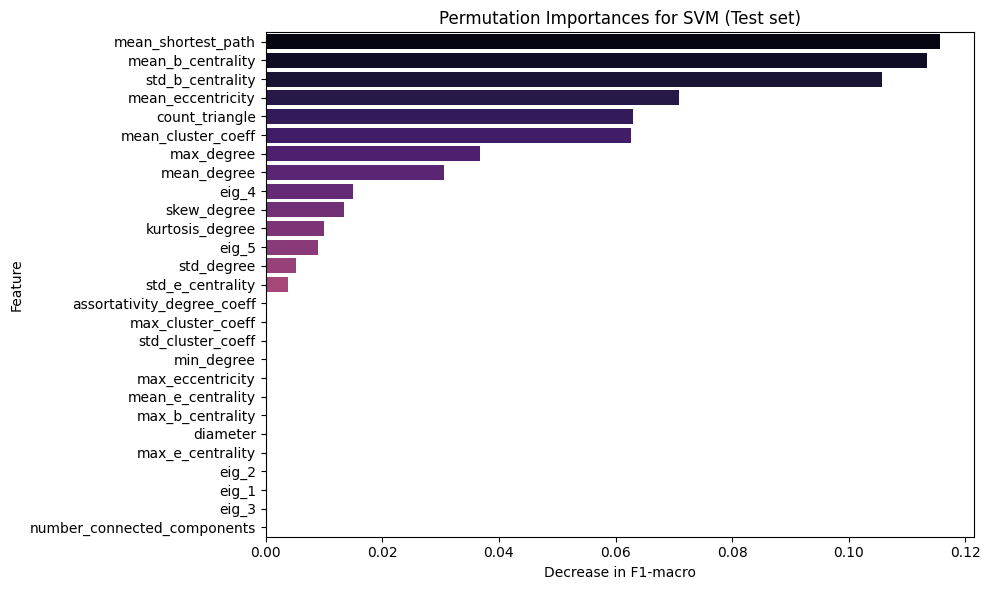

In [84]:
result = permutation_importance(
    fitted_models['SVM_Linear'],
    X_test, y_test,
    n_repeats=30,
    random_state=seed,
    scoring='f1_macro'
)

svm_importances = pd.Series(
    result.importances_mean,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=svm_importances.values,
    y=svm_importances.index,
    hue=svm_importances.index,
    palette='magma'
)
plt.title('Permutation Importances for SVM (Test set)')
plt.xlabel('Decrease in F1-macro')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Importance of features : GCN

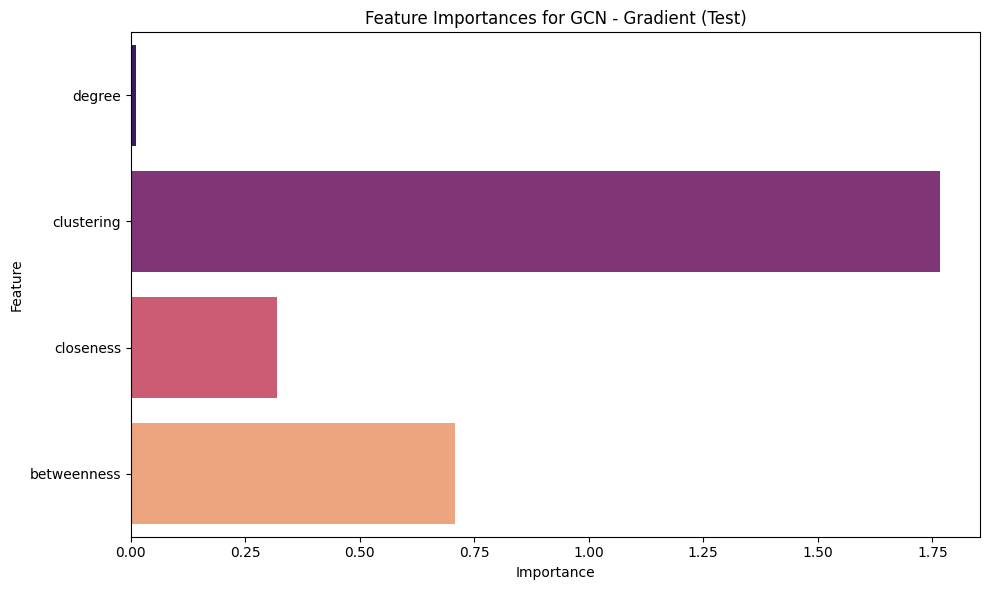

In [85]:
gcn_importances = gcnf.gradient_feature_importance(model_gcn, test_loader)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=gcn_importances.values(),
    y=gcn_importances.keys(),
    hue=gcn_importances.keys(),
    palette='magma'
)
plt.title('Feature Importances for GCN - Gradient (Test)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Density-Controlled + Different Graph Sizes Experiment


Density-controlled setup with different graph sizes between train and test.

For runtime purposes: training graphs use `n = 100` and test graphs use `n = 200` (instead of just 200).

In [86]:
avg_degrees = 8
n_train = 100
n_test = 200

graph_dataset_train = gf.create_graph_dataset(n_train, avg_degrees, 170) # We want 680 graphs in train + val sets (like in previous exp)
graph_dataset_test = gf.create_graph_dataset(n_test, avg_degrees, 30) # We want 120 graphs (like in previous exp)
print('Graphs dataset created.')

Graphs dataset created.


## Random Forest & SVM

In [87]:
# Creating and splitting features datasets

features_dataset_train = gf.create_features_dataset(graph_dataset_train)
X = features_dataset_train.drop(columns = ['target'])
y = features_dataset_train['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.15, stratify = y, random_state=seed)

features_dataset_test = gf.create_features_dataset(graph_dataset_test)
X_test = features_dataset_test.drop(columns = ['target'])
y_test = features_dataset_test['target']

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (578, 27) Val: (102, 27) Test: (120, 27)


In [88]:
# Training the Random Forest & SVM models

models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1),
    'SVM_Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='linear', C=10, gamma='scale'))
    ])
}

fitted_models = {}
val_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    val_rows.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_macro_f1': f1_score(y_val, y_val_pred, average='macro')
    })

    fitted_models[name] = model

for m in val_rows:
    print(f"Model : {m['model']} ", '\n', f"Val Accuracy : {m['val_accuracy']}", '\n', f"Val F1: {m['val_macro_f1']}", '\n')

Model : RandomForest  
 Val Accuracy : 1.0 
 Val F1: 1.0 

Model : SVM_Linear  
 Val Accuracy : 1.0 
 Val F1: 1.0 



## GCN

In [89]:
# Creating 3 sets : Train, Val, Test
train_graphs, val_graphs = train_test_split(
    graph_dataset_train,
    test_size = 0.15,
    random_state = seed,
    stratify = [t for _, t in graph_dataset_train]
    )

train_pyg = gcnf.nx_to_pyg(train_graphs)
val_pyg = gcnf.nx_to_pyg(val_graphs)
test_pyg = gcnf.nx_to_pyg(graph_dataset_test)

print('Train:', len(train_graphs), 'Val:', len(val_graphs), 'Test:', len(graph_dataset_test))

# Creating dataloaders with a batch_size of 16
train_loader = DataLoader(train_pyg, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_pyg, batch_size = 16, shuffle = False)
test_loader = DataLoader(test_pyg, batch_size = 16, shuffle = False)

Train: 578 Val: 102 Test: 120


In [90]:
# Creating the GCN

model_gcn = gcnf.GCN(hidden_channels=64)
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

print('GCN created.')

GCN created.


In [91]:
# Training the GCN

def train():
    model_gcn.train()
    for data in train_loader:
        out = model_gcn(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def test(loader):
    model_gcn.eval()
    correct = 0
    with torch.no_grad():
        for data in loader:
            out = model_gcn(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)

for epoch in range(1, 51):
    train()
    if epoch % 10 == 0:
        val_acc = test(val_loader)
        print(f'Epoch: {epoch:03d}, Val Acc: {val_acc:.4f}')

Epoch: 010, Val Acc: 0.8824
Epoch: 020, Val Acc: 0.8725
Epoch: 030, Val Acc: 0.7941
Epoch: 040, Val Acc: 0.9020
Epoch: 050, Val Acc: 0.9608


## Results

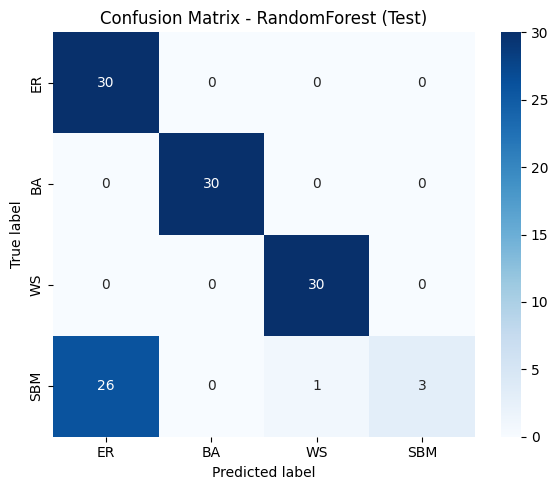

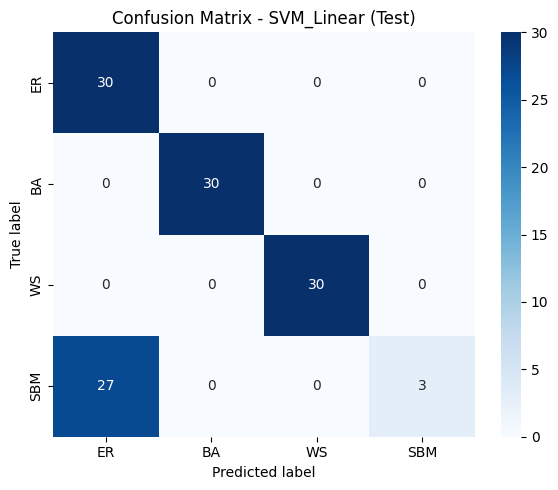

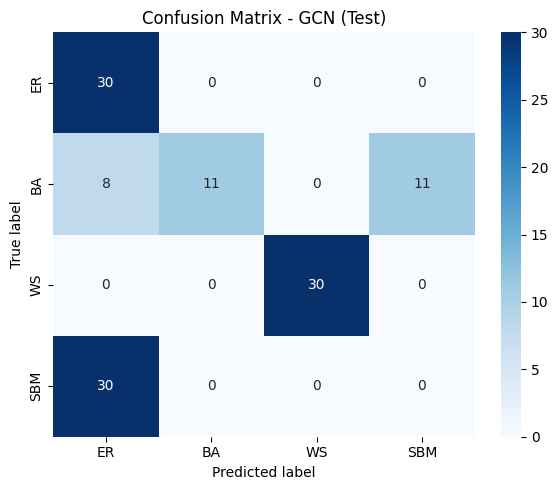

In [92]:
# Combine all models for evaluation
# fitted_models already contains RandomForest and SVM_Linear from previous steps
all_models_to_evaluate = fitted_models.copy()
all_models_to_evaluate['GCN'] = model_gcn

# Prepare labels and class names
labels = [0, 1, 2, 3]
class_names = ['ER', 'BA', 'WS', 'SBM']

results_rows = []

for name, model in all_models_to_evaluate.items():
    if name == 'GCN':
        y_test_true, y_test_pred = gcnf.get_gcn_predictions(model, test_loader)
    else:
        y_test_pred = model.predict(X_test)
        y_test_true = y_test

    accuracy = accuracy_score(y_test_true, y_test_pred)
    macro_f1 = f1_score(y_test_true, y_test_pred, average='macro')

    results_rows.append({
        'model': name,
        'test_accuracy': accuracy,
        'test_macro_f1': macro_f1
    })

    cm = confusion_matrix(y_test_true, y_test_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix - {name} (Test)')
    plt.tight_layout()
    plt.show()

# Density-Controlled + Random Edge Perturbations Experiment


Density-controlled setup (average degree = 8), then evaluate robustness to noisy edges.

We train on clean graphs and test on both clean and perturbed graphs.

In [94]:
import random

def perturb_graph_edges(G, perturb_fraction, seed):
    """Randomly remove and add edges while keeping graph size and edge count roughly stable."""
    rng = random.Random(seed)
    H = G.copy()

    m = H.number_of_edges()
    num_changes = int(perturb_fraction * m)
    if num_changes == 0:
        return H

    edges = list(H.edges())
    edges_to_remove = rng.sample(edges, num_changes)
    H.remove_edges_from(edges_to_remove)

    n = H.number_of_nodes()
    added = 0
    max_attempts = 20 * num_changes
    attempts = 0

    while added < num_changes and attempts < max_attempts:
        u = rng.randrange(n)
        v = rng.randrange(n)
        attempts += 1
        if u == v or H.has_edge(u, v):
            continue
        H.add_edge(u, v)
        added += 1

    return H


In [95]:
n = 200
avg_degrees = 8
num_graphs_per_class = 200
perturb_fraction = 0.10

graph_dataset = gf.create_graph_dataset(n, avg_degrees, num_graphs_per_class)
train_graphs, val_graphs, test_graphs = gf.splitting(seed=seed, X=graph_dataset)

test_noised_graphs = [
    (perturb_graph_edges(e[0], perturb_fraction=perturb_fraction, seed=seed + i), e[1])
    for i, e in enumerate(test_graphs)
]

print('Graphs dataset created.')
print('Train:', len(train_graphs), 'Val:', len(val_graphs),
      'Test:', len(test_graphs), 'Test Noised:', len(test_noised_graphs))

Graphs dataset created.
Train: 559 Val: 121 Test: 120 Test Noised: 120


## Random Forest & SVM

In [96]:
# Creating features datasets

features_train = gf.create_features_dataset(train_graphs)
X_train = features_train.drop(columns=['target'])
y_train = features_train['target']

features_val = gf.create_features_dataset(val_graphs)
X_val = features_val.drop(columns=['target'])
y_val = features_val['target']

features_test = gf.create_features_dataset(test_graphs)
X_test = features_test.drop(columns=['target'])
y_test = features_test['target']

features_test_noised = gf.create_features_dataset(test_noised_graphs)
X_test_noised = features_test_noised.drop(columns=['target'])
y_test_noised = features_test_noised['target']

print('Train:', X_train.shape, 'Val:', X_val.shape,
      'Test:', X_test.shape, 'Test Noised:', X_test_noised.shape)

Train: (559, 27) Val: (121, 27) Test: (120, 27) Test Noised: (120, 27)


In [97]:
# Training the Random Forest & SVM models

models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1),
    'SVM_Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='linear', C=10, gamma='scale'))
    ])
}

fitted_models = {}
val_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    val_rows.append({
        'model': name,
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_macro_f1': f1_score(y_val, y_val_pred, average='macro')
    })
    fitted_models[name] = model

for m in val_rows:
    print(f"Model : {m['model']} ", '\n', f"Val Accuracy : {m['val_accuracy']}", '\n', f"Val F1: {m['val_macro_f1']}", '\n')

Model : RandomForest  
 Val Accuracy : 1.0 
 Val F1: 1.0 

Model : SVM_Linear  
 Val Accuracy : 1.0 
 Val F1: 1.0 



## GCN

In [98]:
# Creating 3 sets : Train, Val, Test
train_pyg        = gcnf.nx_to_pyg(train_graphs)
val_pyg          = gcnf.nx_to_pyg(val_graphs)
test_pyg         = gcnf.nx_to_pyg(test_graphs)
test_noised_pyg  = gcnf.nx_to_pyg(test_noised_graphs)

print('Train:', len(train_pyg), 'Val:', len(val_pyg),
      'Test:', len(test_pyg), 'Test Noised:', len(test_noised_pyg))

# Creating dataloaders with a batch_size of 16
train_loader        = DataLoader(train_pyg,       batch_size=16, shuffle=True)
val_loader          = DataLoader(val_pyg,         batch_size=16, shuffle=False)
test_loader         = DataLoader(test_pyg,        batch_size=16, shuffle=False)
test_noised_loader  = DataLoader(test_noised_pyg, batch_size=16, shuffle=False)

Train: 559 Val: 121 Test: 120 Test Noised: 120


In [99]:
# Creating the GCN

model_gcn = gcnf.GCN(hidden_channels=64)
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

print('GCN created.')

GCN created.


In [100]:
# Training the GCN

def train():
    model_gcn.train()
    for data in train_loader:
        out = model_gcn(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def test(loader):
    model_gcn.eval()
    correct = 0
    with torch.no_grad():
        for data in loader:
            out = model_gcn(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)

for epoch in range(1, 51):
    train()
    if epoch % 10 == 0:
        val_acc = test(val_loader)
        print(f'Epoch: {epoch:03d}, Val Acc: {val_acc:.4f}')

Epoch: 010, Val Acc: 0.9587
Epoch: 020, Val Acc: 0.9256
Epoch: 030, Val Acc: 0.9917
Epoch: 040, Val Acc: 0.8678
Epoch: 050, Val Acc: 0.9835


## Results


=== Test (clean) ===


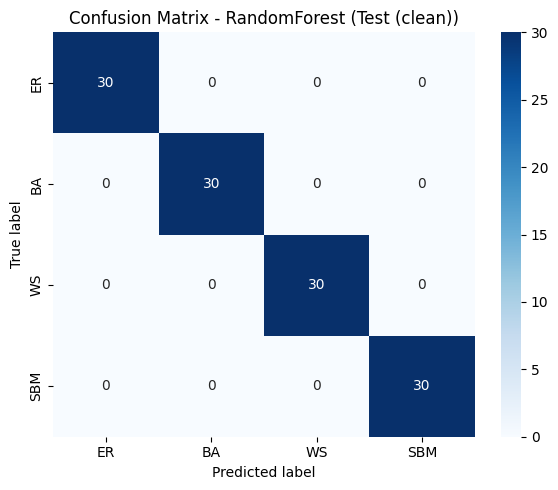

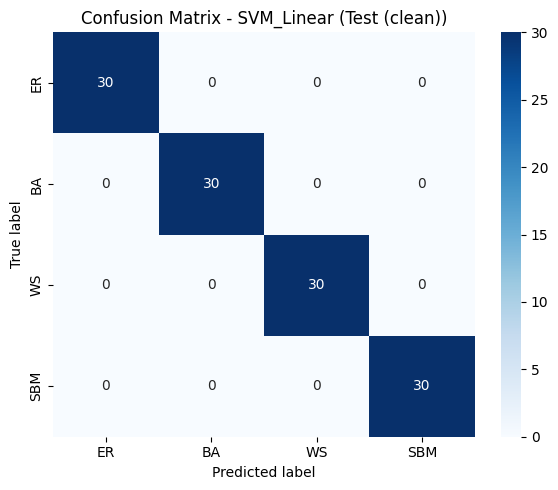

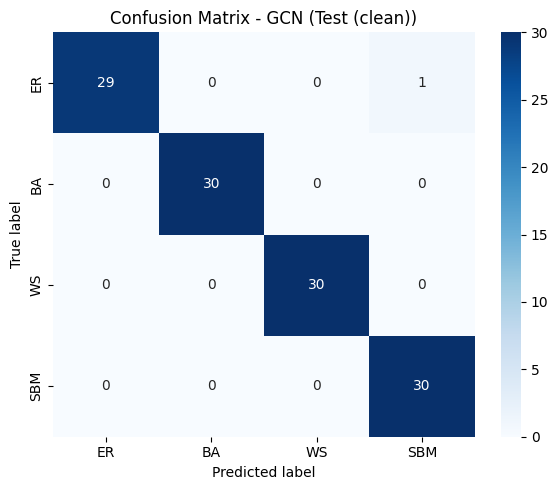


=== Test (noised) ===


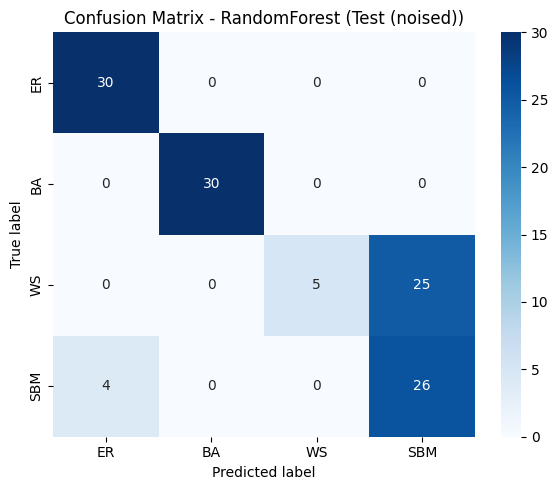

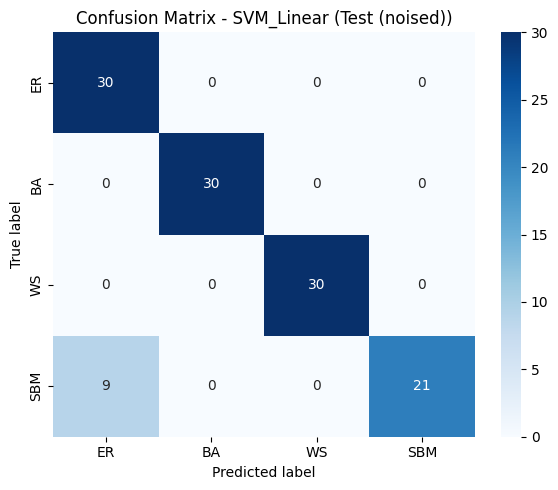

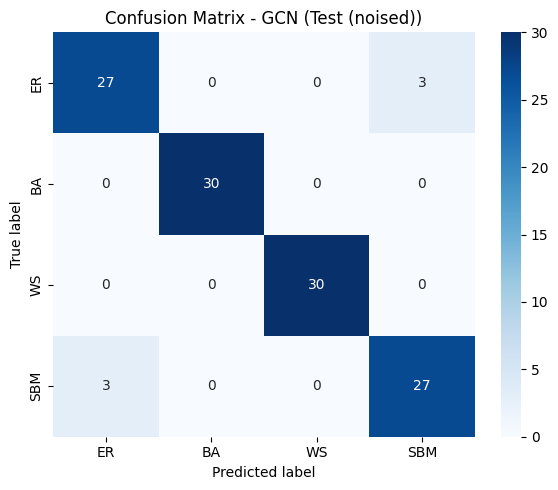

In [101]:
# Combine all models for evaluation
# fitted_models already contains RandomForest and SVM_Linear from previous steps
all_models_to_evaluate = fitted_models.copy()
all_models_to_evaluate['GCN'] = model_gcn

# Prepare labels and class names
labels = [0, 1, 2, 3]
class_names = ['ER', 'BA', 'WS', 'SBM']

results_rows = []

test_sets = [
    ('Test (clean)',  X_test,        y_test,        test_loader),
    ('Test (noised)', X_test_noised, y_test_noised, test_noised_loader),
]

for test_name, X_t, y_t, loader in test_sets:
    print(f'\n=== {test_name} ===')
    for name, model in all_models_to_evaluate.items():
        if name == 'GCN':
            y_test_true, y_test_pred = gcnf.get_gcn_predictions(model, loader)
        else:
            y_test_pred = model.predict(X_t)
            y_test_true = y_t

        accuracy = accuracy_score(y_test_true, y_test_pred)
        macro_f1 = f1_score(y_test_true, y_test_pred, average='macro')

        results_rows.append({
            'test_set':       test_name,
            'model':          name,
            'test_accuracy':  accuracy,
            'test_macro_f1':  macro_f1
        })

        cm = confusion_matrix(y_test_true, y_test_pred, labels=labels)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.title(f'Confusion Matrix - {name} ({test_name})')
        plt.tight_layout()
        plt.show()